In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
import time
import copy
import os
import pickle

import import_ipynb
import importlib
import functions as fc
importlib.reload(fc)

print(os.getcwd())

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\Exercise2


In [2]:
bean_train = pd.read_csv("datasets/bean_train_balanced.csv")
bean_test = pd.read_csv("datasets/bean_test.csv")

----------------------------------------------------------------------------------------------
-------------------------------------- ORIGINAL DATASET --------------------------------------
----------------------------------------------------------------------------------------------

In [3]:
X_train = bean_train.drop('Class', axis = 1)
X_test = bean_test.drop('Class', axis = 1)
y_train = bean_train['Class']
y_test = bean_test['Class']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### Fit the model

In [4]:
model = LogisticRegression(
    penalty="l2",
    C=1,
    max_iter=1000,
    random_state=42
)
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

### Prediction and utility

In [5]:
print("Training set: ")
fc.predict_multiclass(model, X_train_sc, y_train, conf_matrix=False)

Training set: 
---------------------------------------
Accuracy:  0.9331
Precision: 0.9337
Recall:    0.9331
F1 Score:  0.9333
---------------------------------------


---------------------------------------
Accuracy:  0.9269
Precision: 0.9289
Recall:    0.9269
F1 Score:  0.9273
---------------------------------------
                 Predicted BARBUNYA  Predicted BOMBAY  Predicted CALI  \
Actual BARBUNYA                 246                 0              12   
Actual BOMBAY                     0               117               0   
Actual CALI                      13                 0             297   
Actual DERMASON                   0                 0               0   
Actual HOROZ                      2                 0               3   
Actual SEKER                      8                 0               0   
Actual SIRA                       0                 0               2   

                 Predicted DERMASON  Predicted HOROZ  Predicted SEKER  \
Actual BARBUNYA                   0                0                0   
Actual BOMBAY                     0                0                0   
Actual CALI                       0         

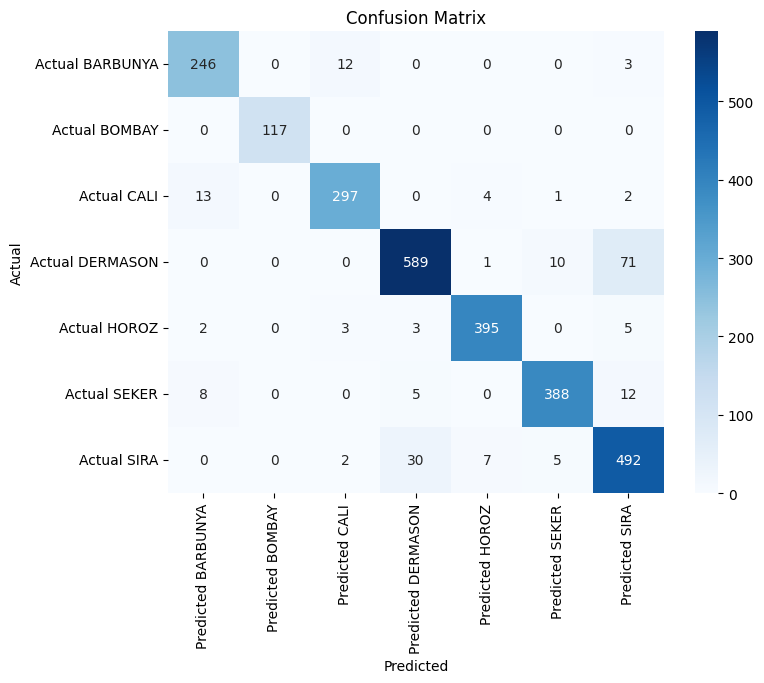

Saved results to results/model_results_bean.xlsx


In [6]:
fc.predict_multiclass_save_results(
    model,
    X_test_sc,
    y_test,
    conf_matrix = True,
    perturbation_type="Original_balanced",
    epsilon=0,
    output_file="results/model_results_bean.xlsx"
)


In [7]:
fc.cross_validate_model(model, X_train_sc, y_train, cv=10, bivariate = False)

Accuracy: 0.9329
Precision: 0.9337
Recall: 0.9329
F1 Score: 0.9331
Prediction time:  5.542273759841919


{'fit_time': array([0.59234595, 0.58400345, 0.58811903, 0.47462535, 0.59291077,
        0.48373079, 0.45877504, 0.48566389, 0.48487782, 0.46474886]),
 'score_time': array([0.03331637, 0.03700423, 0.02824473, 0.0312767 , 0.03193641,
        0.02818322, 0.02779102, 0.02805042, 0.02546406, 0.02762032]),
 'test_accuracy': array([0.93442623, 0.93641331, 0.92995529, 0.92896175, 0.93790363,
        0.93588469, 0.92445328, 0.93538767, 0.93439364, 0.93141153]),
 'test_precision': array([0.93574404, 0.93684538, 0.92993506, 0.92964816, 0.93851674,
        0.93628187, 0.92543645, 0.93622864, 0.93507089, 0.93280762]),
 'test_recall': array([0.93442623, 0.93641331, 0.92995529, 0.92896175, 0.93790363,
        0.93588469, 0.92445328, 0.93538767, 0.93439364, 0.93141153]),
 'test_f1': array([0.93469387, 0.93648262, 0.92985864, 0.92911947, 0.93803191,
        0.93589884, 0.92479998, 0.93561901, 0.93446914, 0.9317762 ])}

In [8]:
best_model, best_params = fc.hyperparameterTuning_save_Results(
    X_train_sc, 
    y_train, 
    cv=10, bivariate = False, 
    perturbation_type="Original_hpt_balanced",
    epsilon=0,
    output_file="results/model_results_bean.xlsx")

Best parameters: {'C': 100}
Accuracy : 0.9335
Precision: 0.9343
Recall   : 0.9335
F1 Score : 0.9337
Time     : 16.23 s


In [9]:
X_all = pd.concat([X_train, X_test], axis=0)
orig_confidence_scores = model.predict_proba(X_all)

with open("orig_confidence_scores_bean_balanced.pkl", "wb") as f:
    pickle.dump(orig_confidence_scores, f)

c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
-------------------------------------- INPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

In [10]:
ranges = [[10000, 300000], [500, 2000], [100, 750], [100, 750],
       [1,3], [0,1], [10000, 300000], [100, 700], [0,1],
       [0,1], [0.2,1], [0.5,1], [0, 0.2], [0, 0.1],
       [0.2,1], [0.9, 1]]
print(ranges)

sensitivity = []
for range in ranges:
    sensitivity.append(range[1]-range[0])
print(sensitivity)

[[10000, 300000], [500, 2000], [100, 750], [100, 750], [1, 3], [0, 1], [10000, 300000], [100, 700], [0, 1], [0, 1], [0.2, 1], [0.5, 1], [0, 0.2], [0, 0.1], [0.2, 1], [0.9, 1]]
[290000, 1500, 650, 650, 2, 1, 290000, 600, 1, 1, 0.8, 0.5, 0.2, 0.1, 0.8, 0.09999999999999998]


In [11]:
epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_datasets = {}

np.random.seed(42)
for e in epsilon_values:
    X_train_perturbed = X_train.copy()
    d = X_train_perturbed.shape[1]

    for i, var in enumerate(X_train.columns):
        eps_j = e # The paper uses eps_j = e/d, but this leades to huge errors
        scale = sensitivity[i] / eps_j   
        noise = np.random.laplace(loc=0,scale=scale,size=len(X_train))

        lower, upper = ranges[i]
        X_train_perturbed[var] = (
            X_train[var] + noise
        ).clip(lower=lower, upper=upper)

    perturbed_datasets[e] = X_train_perturbed

### Fit the model with the new datasets

In [12]:
input_confidence_scores = {}

for e in epsilon_values:
    input_model = copy.deepcopy(model)

    X_train_input = perturbed_datasets[e]
    scaler = StandardScaler()
    X_train_input_sc = scaler.fit_transform(X_train_input)
    X_test_input_sc = scaler.transform(X_test)

    input_model.fit(X_train_input_sc, y_train)

    # Predict on training set
    print("Training set: ")
    fc.predict_multiclass(input_model, X_train_input_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_multiclass_save_results(
        input_model,
        X_test_input_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Input_balanced",
        epsilon=e,
        output_file="results/model_results_bean.xlsx"
    )

    fc.hyperparameterTuning_save_Results(X_train_input_sc, y_train, cv=10, bivariate = False, perturbation_type="Input_hpt_balanced",
        epsilon=e, output_file="results/model_results_bean.xlsx")

    #NEEDED FOR THE MEMBERSHIP ATTACK
    X_all = pd.concat([X_train, X_test], axis=0)
    input_confidence_scores[e] = input_model.predict_proba(X_all)

with open("input_confidence_scores_bean_balanced.pkl", "wb") as f:
    pickle.dump(input_confidence_scores, f)

Training set: 
---------------------------------------
Accuracy:  0.1599
Precision: 0.1600
Recall:    0.1599
F1 Score:  0.1571
---------------------------------------
---------------------------------------
Accuracy:  0.2839
Precision: 0.8167
Recall:    0.2839
F1 Score:  0.1405
---------------------------------------
Saved results to results/model_results_bean.xlsx
Best parameters: {'C': 0.1}
Accuracy : 0.1472
Precision: 0.1474
Recall   : 0.1472
F1 Score : 0.1448
Time     : 1.28 s
Training set: 


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---------------------------------------
Accuracy:  0.2324
Precision: 0.2134
Recall:    0.2324
F1 Score:  0.1973
---------------------------------------
---------------------------------------
Accuracy:  0.5417
Precision: 0.5381
Recall:    0.5417
F1 Score:  0.4389
---------------------------------------
Saved results to results/model_results_bean.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.2276
Precision: 0.2043
Recall   : 0.2276
F1 Score : 0.1909
Time     : 1.57 s


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Training set: 
---------------------------------------
Accuracy:  0.4867
Precision: 0.4679
Recall:    0.4867
F1 Score:  0.4735
---------------------------------------
---------------------------------------
Accuracy:  0.7752
Precision: 0.7819
Recall:    0.7752
F1 Score:  0.7572
---------------------------------------
Saved results to results/model_results_bean.xlsx
Best parameters: {'C': 1}
Accuracy : 0.4840
Precision: 0.4652
Recall   : 0.4840
F1 Score : 0.4707
Time     : 2.73 s


...

c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Training set: 
---------------------------------------
Accuracy:  0.9090
Precision: 0.9095
Recall:    0.9090
F1 Score:  0.9091
---------------------------------------
---------------------------------------
Accuracy:  0.9207
Precision: 0.9223
Recall:    0.9207
F1 Score:  0.9209
---------------------------------------
Saved results to results/model_results_bean.xlsx
Best parameters: {'C': 1}
Accuracy : 0.9068
Precision: 0.9076
Recall   : 0.9068
F1 Score : 0.9070
Time     : 5.09 s


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Training set: 
---------------------------------------
Accuracy:  0.9255
Precision: 0.9259
Recall:    0.9255
F1 Score:  0.9256
---------------------------------------
---------------------------------------
Accuracy:  0.9258
Precision: 0.9276
Recall:    0.9258
F1 Score:  0.9262
---------------------------------------
Saved results to results/model_results_bean.xlsx
Best parameters: {'C': 0.1}
Accuracy : 0.9242
Precision: 0.9248
Recall   : 0.9242
F1 Score : 0.9243
Time     : 6.16 s


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
------------------------------------- OUTPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

In [13]:
n = X_train.shape[0]
#C_x = np.max(np.linalg.norm(X_train, axis=1))
lambda_reg = 1 / model.C
sensitivity = (2) / (lambda_reg * n)

epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_coefficients = {}

np.random.seed(42)
for e in epsilon_values:
    coef_noise = np.random.laplace(loc=0,scale=sensitivity / e,size=model.coef_.shape)
    intercept_noise = np.random.laplace(loc=0,scale=sensitivity / 3,size=model.intercept_.shape)
    perturbed_coefficients[e] = {
        "coef": model.coef_ + coef_noise,
        "intercept": model.intercept_ + intercept_noise
    }

In [14]:
output_confidence_scores = {}

for e in epsilon_values:
    output_model = copy.deepcopy(model)

    output_model.coef_ = perturbed_coefficients[e]["coef"]
    output_model.intercept_ = perturbed_coefficients[e]["intercept"]

    # Predict on training set
    print("Training set: ")
    fc.predict_multiclass(output_model, X_train_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_multiclass_save_results(
        output_model,
        X_test_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Output_balanced",
        epsilon=e,
        output_file="results/model_results_bean.xlsx"
    )

    #NEEDED FOR THE MEMBERSHIP ATTACK
    X_all = pd.concat([X_train, X_test], axis=0)
    output_confidence_scores[e] = output_model.predict_proba(X_all)

with open("output_confidence_scores_bean_balanced.pkl", "wb") as f:
    pickle.dump(output_confidence_scores, f)

Training set: 
---------------------------------------
Accuracy:  0.9332
Precision: 0.9338
Recall:    0.9332
F1 Score:  0.9334
---------------------------------------
---------------------------------------
Accuracy:  0.9269
Precision: 0.9289
Recall:    0.9269
F1 Score:  0.9273
---------------------------------------
Saved results to results/model_results_bean.xlsx
Training set: 


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---------------------------------------
Accuracy:  0.9331
Precision: 0.9337
Recall:    0.9331
F1 Score:  0.9333
---------------------------------------
---------------------------------------
Accuracy:  0.9269
Precision: 0.9289
Recall:    0.9269
F1 Score:  0.9273
---------------------------------------
Saved results to results/model_results_bean.xlsx
Training set: 


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---------------------------------------
Accuracy:  0.9331
Precision: 0.9337
Recall:    0.9331
F1 Score:  0.9333
---------------------------------------
---------------------------------------
Accuracy:  0.9269
Precision: 0.9289
Recall:    0.9269
F1 Score:  0.9273
---------------------------------------
Saved results to results/model_results_bean.xlsx


...

c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---------------------------------------
Accuracy:  0.9331
Precision: 0.9337
Recall:    0.9331
F1 Score:  0.9333
---------------------------------------
---------------------------------------
Accuracy:  0.9269
Precision: 0.9289
Recall:    0.9269
F1 Score:  0.9273
---------------------------------------
Saved results to results/model_results_bean.xlsx
Training set: 


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---------------------------------------
Accuracy:  0.9331
Precision: 0.9337
Recall:    0.9331
F1 Score:  0.9333
---------------------------------------
---------------------------------------
Accuracy:  0.9269
Precision: 0.9289
Recall:    0.9269
F1 Score:  0.9273
---------------------------------------
Saved results to results/model_results_bean.xlsx


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
------------------------------------ INTERNAL PERTUBATION ------------------------------------
----------------------------------------------------------------------------------------------

In [15]:

data_norm = np.max(np.linalg.norm(X_train_sc, axis=1))
print("data_norm (max L2 norm of a scaled training row):", data_norm)


data_norm (max L2 norm of a scaled training row): 17.42585990222406


In [16]:
epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]


internal_models = fc.internal_perturbation_save_results(
    "bean",
    X_train_sc,
    y_train,
    X_test_sc,
    y_test,
    epsilon_values=epsilon_values,
    data_norm=data_norm,
    C=model.C,
    bivariate=False,
    output_file="results/model_results_bean.xlsx",
    perturbation_type="Internal_balanced"
)




---------------------------------------
Epsilon: 0.1
Accuracy: 0.1142
Precision: 0.0875
Recall: 0.1142
F1 Score: 0.0971
Time: 0.32 s
---------------------------------------
---------------------------------------
Epsilon: 1
Accuracy: 0.3999
Precision: 0.3883
Recall: 0.3999
F1 Score: 0.3603
Time: 0.34 s
---------------------------------------
---------------------------------------
Epsilon: 5
Accuracy: 0.7830
Precision: 0.7870
Recall: 0.7830
F1 Score: 0.7830
Time: 0.49 s
---------------------------------------
---------------------------------------
Epsilon: 10
Accuracy: 0.8502
Precision: 0.8543
Recall: 0.8502
F1 Score: 0.8504
Time: 0.57 s
---------------------------------------
---------------------------------------
Epsilon: 30
Accuracy: 0.8505
Precision: 0.8701
Recall: 0.8505
F1 Score: 0.8544
Time: 0.68 s
---------------------------------------
---------------------------------------
Epsilon: 50
Accuracy: 0.9093
Precision: 0.9123
Recall: 0.9093
F1 Score: 0.9098
Time: 0.79 s
---------